# Outlier Removal via IQR

`12_Outlier.ipynb` proved outliers distort statistics, explained why that
matters for ML models, and detected them with the box-plot/IQR method —
Section 6 there removed `ApplicantIncome`'s outliers as a quick closing
example. This notebook is the deeper, dedicated version of that removal
step, worked through on `CoapplicantIncome`:

1. Recompute the IQR bounds (`Q1`, `Q3`, `min_range`, `max_range`) —
   same formulas as the whiteboard: `IQR = Q3 − Q1`, `min = Q1 − 1.5×IQR`,
   `max = Q3 + 1.5×IQR`.
2. Filter the outliers out, and **prove** the filter actually worked —
   before/after box plots and distribution plots side by side, not just a
   shape number.
3. Check the impact on `mean`/`std` — the same statistics `12_Outlier.ipynb`
   Section 1 showed outliers distort, now measured going the other direction.
4. Compare removal against the alternatives (capping, trimming, transforming).
5. Combine `CoapplicantIncome` **and** `ApplicantIncome` cleaning into one
   final dataset.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("loans.csv")
dataset.shape

(618, 13)

618 rows, 13 columns — the baseline to measure every filter against.

## 1. The IQR Bounds

Same three formulas as the whiteboard, on `CoapplicantIncome` this time
instead of `ApplicantIncome`.

In [3]:
q1 = dataset["CoapplicantIncome"].quantile(0.25)
q3 = dataset["CoapplicantIncome"].quantile(0.75)
q1, q3

(np.float64(0.0), np.float64(2217.75))

`Q1 = 0.0` — a quarter of applicants have **zero** co-applicant income (no
co-applicant, or a co-applicant who doesn't earn). `Q3 = 2217.75` — the
75th-percentile co-applicant earns that much or less. Nothing wrong with
`Q1 = 0` here; it's a real, common value in this column, not a missing-data
artifact.

In [4]:
IQR = q3-q1
IQR

np.float64(2217.75)

The width of the middle 50% of the data: `2217.75`.

In [5]:
min_range = q1 - (1.5*IQR)
max_range = q3 + (1.5*IQR)
min_range , max_range

(np.float64(-3326.625), np.float64(5544.375))

`min_range = -3326.6`, `max_range = 5544.4`. The lower bound is
**negative** — and `CoapplicantIncome` can never be negative — so no row
could ever fall below it. That's worth confirming rather than assuming, next.

In [6]:
both_bounds = dataset[(dataset["CoapplicantIncome"] >= min_range) & (dataset["CoapplicantIncome"] <= max_range)]
upper_only = dataset[dataset["CoapplicantIncome"] <= max_range]
both_bounds.shape, upper_only.shape

((603, 13), (603, 13))

**Confirms it:** filtering with both bounds and filtering with only
`<= max_range` produce the exact same shape. So the single-sided filter
(`dataset["CoapplicantIncome"] <= max_range`, no lower-bound check) isn't a
shortcut that risks missing anything here — it's the correct, minimal filter
for a column that's bounded at zero in reality. That won't be true for every
column (e.g. `ApplicantIncome`'s bound was also negative in `12_Outlier.ipynb`
for the same reason, but a column like temperature or account balance really
can go negative, where dropping the lower-bound check would be a genuine bug,
not a harmless simplification).

## 2. Filtering — and Proving It Worked

`12_Outlier.ipynb` Section 3 already counted **15** `CoapplicantIncome` rows
past `max_range`. Filtering them out and checking the shape is a number;
looking at the box plot before and after is the visual proof.

In [7]:
new_dataset = dataset[dataset["CoapplicantIncome"]<=max_range]
dataset.shape, new_dataset.shape

((618, 13), (603, 13))

`(618, 13) → (603, 13)` — 15 rows dropped, matching the count from `12_Outlier.ipynb` exactly.

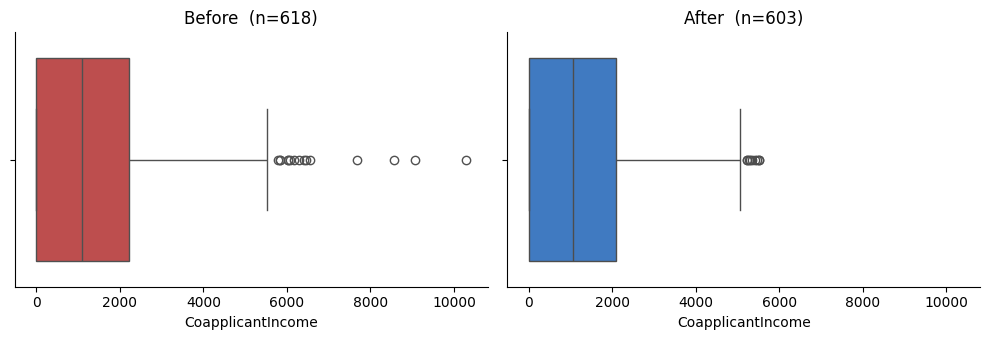

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
sns.boxplot(x="CoapplicantIncome", data=dataset, color="#d03b3b", ax=axes[0])
axes[0].set_title(f"Before  (n={dataset.shape[0]})")
sns.boxplot(x="CoapplicantIncome", data=new_dataset, color="#2a78d6", ax=axes[1])
axes[1].set_title(f"After  (n={new_dataset.shape[0]})")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Visualization 1 — before/after box plots, side by side, same x-axis
scale.** Red (before) shows the string of outlier dots past the right
whisker; blue (after) shows them gone — the whisker itself is now the
rightmost thing in the plot. Same color convention as `12_Outlier.ipynb`:
red for the flagged/unfiltered state, blue for the clean one.

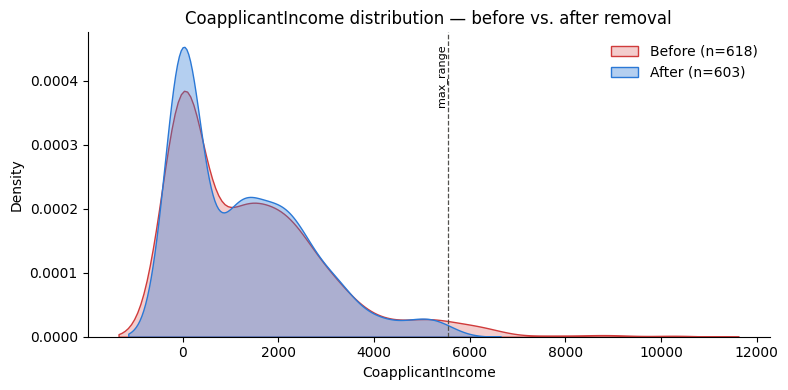

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(dataset["CoapplicantIncome"], color="#d03b3b", fill=True, alpha=0.25, label=f"Before (n={dataset.shape[0]})", ax=ax)
sns.kdeplot(new_dataset["CoapplicantIncome"], color="#2a78d6", fill=True, alpha=0.35, label=f"After (n={new_dataset.shape[0]})", ax=ax)
ax.axvline(max_range, color="#52514e", linestyle="--", linewidth=0.9)
ax.text(max_range, ax.get_ylim()[1]*0.96, "max_range", rotation=90, va="top", ha="right", fontsize=8)
ax.set_title("CoapplicantIncome distribution — before vs. after removal")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Visualization 2 — the distribution version of the same proof.** The red
curve (before) has real density stretching well past `max_range`; the blue
curve (after) is cut off cleanly at that line — nothing beyond it, because
nothing beyond it survived the filter. Both curves overlaid on the same axes
so the shortened tail is directly comparable, not just eyeballed across two
separate plots.

## 3. The Impact on `mean` and `std`

`12_Outlier.ipynb` Section 1 proved outliers inflate the mean and (especially)
the standard deviation, using a toy list. Same measurement, run the other
way — on the real column, before and after removal.

In [10]:
before_mean, before_std = dataset["CoapplicantIncome"].mean(), dataset["CoapplicantIncome"].std()
after_mean, after_std = new_dataset["CoapplicantIncome"].mean(), new_dataset["CoapplicantIncome"].std()

print(f"mean:  {before_mean:.1f} -> {after_mean:.1f}  ({100*(after_mean-before_mean)/before_mean:+.1f}%)")
print(f"std:   {before_std:.1f} -> {after_std:.1f}  ({100*(after_std-before_std)/before_std:+.1f}%)")

mean:  1385.1 -> 1248.6  (-9.9%)
std:   1611.8 -> 1360.1  (-15.6%)


`mean` drops **~10%** (`1385 → 1249`), `std` drops even more, **~16%**
(`1612 → 1360`) — smaller shifts than the toy example's dramatic 3x/30x,
because here only 15 out of 618 rows (2.4%) were removed rather than 1 out
of 9 (11%) — but the *direction* and the *std-drops-more-than-mean* pattern
are identical. This is the real-data confirmation of Section 1's toy-list
result: removing the outliers pulls both statistics back toward where the
bulk of the data actually sits.

## 4. Removal vs. the Alternatives

Dropping rows is the most aggressive option — worth seeing it next to the
others `02_ML_Roadmap.MD` names (cap, remove, transform):

| Approach | What it does | Rows kept? | Best when |
|---|---|---|---|
| **Removal** (this notebook) | Drop any row outside `[min_range, max_range]` | No — loses the row entirely, including its other columns | Outliers are a small share of rows and are likely genuine errors/noise, not rare-but-real cases |
| **Capping / winsorizing** | `series.clip(min_range, max_range)` — squash extreme values *to* the bound instead of dropping them | Yes | The rest of the row is still useful data (e.g. `LoanAmount`, `Credit_History` for this same applicant) |
| **Trimming both tails symmetrically** | Drop a fixed top/bottom percentage (e.g. 1%) regardless of IQR | No | Distribution is heavily skewed and IQR's asymmetry isn't the behavior wanted |
| **Transformation** (e.g. `np.log1p(series)`) | Compress the scale so extreme values stop dominating, without deleting or altering any row's rank | Yes | The column is right-skewed by nature (like income) rather than genuinely erroneous — keeps every data point, just on a friendlier scale |

**Why removal is reasonable here specifically:** the goal on this pass is a
clean baseline column for outlier mechanics, and 15 rows is 2.4% of 618 —
small enough that dropping them doesn't meaningfully shrink the dataset.
For a real modeling pipeline, capping or a log transform would usually be
preferred over removal, precisely because they don't throw away the rest of
that row's information.

## 5. Cleaning Both Income Columns Together

`12_Outlier.ipynb` removed `ApplicantIncome`'s outliers; this notebook just
removed `CoapplicantIncome`'s. A real pipeline wants both applied to the
same final dataset — chaining the two filters.

In [11]:
s = dataset["ApplicantIncome"].dropna()
Q1_app, Q3_app = s.quantile(0.25), s.quantile(0.75)
IQR_app = Q3_app - Q1_app
lo_app, hi_app = Q1_app - 1.5 * IQR_app, Q3_app + 1.5 * IQR_app

cleaned = dataset[(dataset["ApplicantIncome"] >= lo_app) & (dataset["ApplicantIncome"] <= hi_app)]
cleaned = cleaned[cleaned["CoapplicantIncome"] <= max_range]

print("Original:                       ", dataset.shape)
print("After ApplicantIncome filter:   ", (dataset[(dataset["ApplicantIncome"] >= lo_app) & (dataset["ApplicantIncome"] <= hi_app)]).shape)
print("After both filters (chained):   ", cleaned.shape)

Original:                        (618, 13)
After ApplicantIncome filter:    (595, 13)
After both filters (chained):    (581, 13)


`618 → 595 → 581` — the `ApplicantIncome` filter alone drops 23 rows (the
same 21 outliers + 2 `NaN` rows `12_Outlier.ipynb` found), then the
`CoapplicantIncome` filter drops 14 more on top, for **37 rows removed in
total** (`618 - 581`). Not `23 + 15`: some of `CoapplicantIncome`'s 15
outlier rows were likely already gone after the first filter, so the second
filter's *marginal* drop (14) is slightly smaller than its standalone count —
`581` is the number that actually reflects both filters combined.

**One subtlety worth being deliberate about:** `Q1_app`/`Q3_app` here are
computed from the *original* `dataset`, not recomputed from `cleaned` after
the `CoapplicantIncome` filter already ran. That's the right order — IQR
bounds should reflect the data's real spread, not a spread that's already
been narrowed by a previous filter (recomputing on shrinking data would make
each successive filter more aggressive than intended, chasing a moving
target instead of a fixed one).